# Hypothesis 3: iteration improves over a one-shot transformation

We sweep the number of Forest Sketch iterations `T` while keeping the target dimension and downstream model fixed. `T=0` is the initial random projection, and `T=1` is the one-shot tree-path transformation.

In [1]:
import sys
import time
from pathlib import Path

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists():
    notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))

import matplotlib.pyplot as plt
import pandas as pd
from _hypothesis_utils import classification_data, classification_score, downstream_classifier, forest_sketch

,mean_accuracy,std_accuracy,mean_wall,mean_cpu
T,,,,
0,0.640,0.066,0.002,0.017
1,0.657,0.035,0.498,1.035
2,0.635,0.043,1.072,1.175
3,0.644,0.021,0.840,1.511


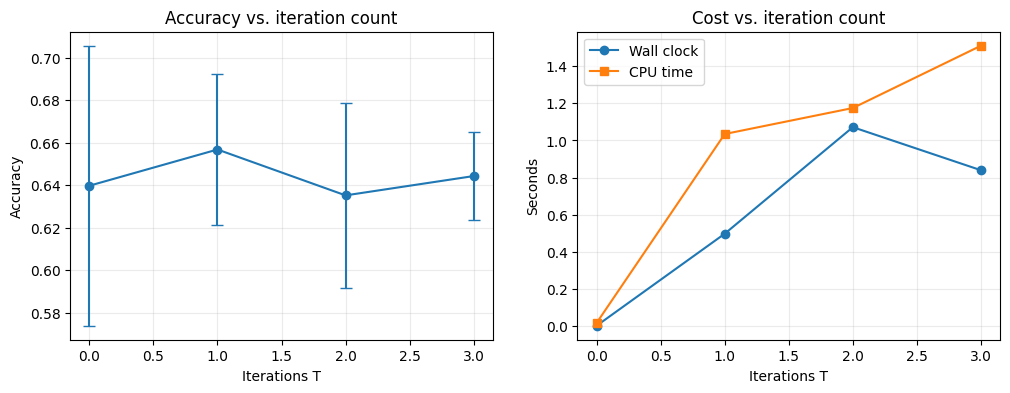

Hypothesis 3: NOT SUPPORTED — T=2 minus T=1 accuracy gain=-0.022


In [2]:
rows = []
for seed in [0, 1]:
    X_train, _, X_test, y_train, _, y_test = classification_data(seed)
    for iterations in [0, 1, 2, 3]:
        representation = forest_sketch(seed, n_components=32, n_iterations=iterations)
        wall_start = time.perf_counter()
        cpu_start = time.process_time()
        X_train_view = representation.fit_transform(X_train, y_train)
        X_test_view = representation.transform(X_test)
        wall_seconds = time.perf_counter() - wall_start
        cpu_seconds = time.process_time() - cpu_start
        accuracy, errors = classification_score(
            downstream_classifier(seed), X_train_view, y_train, X_test_view, y_test
        )
        rows.append({'seed': seed, 'T': iterations, 'accuracy': accuracy, 'errors': errors, 'wall_seconds': wall_seconds, 'cpu_seconds': cpu_seconds})
results = pd.DataFrame(rows)
summary = results.groupby('T').agg(mean_accuracy=('accuracy', 'mean'), std_accuracy=('accuracy', 'std'), mean_wall=('wall_seconds', 'mean'), mean_cpu=('cpu_seconds', 'mean'))
display(summary.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(summary.index, summary.mean_accuracy, yerr=summary.std_accuracy, marker='o', capsize=4)
axes[0].set(xlabel='Iterations T', ylabel='Accuracy', title='Accuracy vs. iteration count')
axes[1].plot(summary.index, summary.mean_wall, marker='o', label='Wall clock')
axes[1].plot(summary.index, summary.mean_cpu, marker='s', label='CPU time')
axes[1].set(xlabel='Iterations T', ylabel='Seconds', title='Cost vs. iteration count')
axes[1].legend()
for axis in axes: axis.grid(alpha=0.25)
plt.show()
gain = summary.loc[2, 'mean_accuracy'] - summary.loc[1, 'mean_accuracy']
print(f'Hypothesis 3: {"SUPPORTED" if gain > 0 else "NOT SUPPORTED"} — T=2 minus T=1 accuracy gain={gain:.3f}')

## Conclusion

**Hypothesis:** reusing the compressed representation in later forest stages improves performance over a one-shot transformation.

**Experiment:** sweep `T` over 0, 1, 2, and 3 on the same difficult classification task across two seeds, keeping `d=32` and the downstream model fixed.

**Measure:** held-out accuracy and integer errors, together with fit-transform wall-clock and CPU time.

**Result:** not supported in this run: mean accuracy at `T=2` was 0.022 below `T=1`.